---------- ✓ Protocol and metadata loaded ----------
metadata         =  {'sess_name': 'kendra_scrappy_0161a', 'probe_label': ['lFEF', 'rFEF'], 'probe_type': ['neuropixel', 'neuropixel'], 'probe_config': ['nhp_long_1.0', 'nhp_long_1.0'], 'hardware_config': ['imec0', 'imec1'], 'probe_depth_mm': [4.3, 5.2], 'probe_gridHole': [['p1', 'l2'], ['a2', 'm2']], 'HEeye_VEeye_diode_pupil': ['10241', '10242', '10243', '10244']}
---------- ✓ Paths established with hash ----------
data_path        =  /ix1/pmayo/lab_NHPdata/kendra_scrappy_0161a_g0/kendra_scrappy_0161a_g0_imec1
figs_path        =  /ix1/pmayo/lab_NHPdata/kendra_scrappy_0161a_g0/figs/f22a3724a90d617234ccfa164a80214d-nodrift-1b0be7a4ec2d87506b4b26c311739e2d/imec1_rFEF
preprocess_hash  =  f22a3724a90d617234ccfa164a80214d
motion_hash      =  nodrift
-------------- ✓ Probe map generated --------------
===== motion screening plotted =====
cutoff_frame      =  119400164
----------- ✓ Motion screening complete -----------


PosixPath('/ix1/pmayo/lab_NHPdata/kendra_scrappy_0161a_g0/figs/f22a3724a90d617234ccfa164a80214d-nodrift-1b0be7a4ec2d87506b4b26c311739e2d/imec1_rFEF')

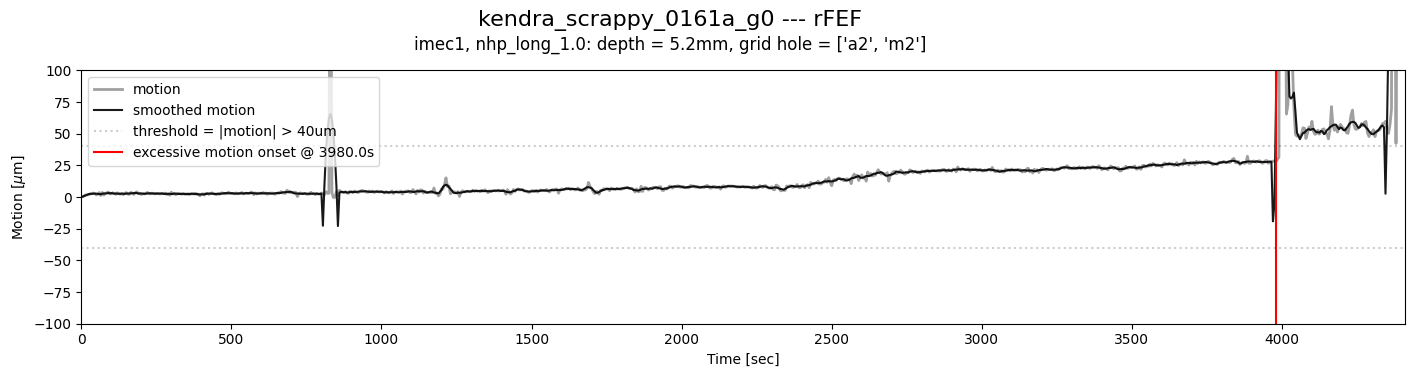

In [10]:
from main_pipeline import run_preprocess

SESSION = 'kendra_scrappy_0161a_g0' #124,157,161, Ya_250502_s388_g0, Ya_250506_s390_g0
PROBE_ID = 1
PROTOCOL = 'np-nodrift-ks4.json'

profile = run_preprocess(SESSION, probe_id=PROBE_ID, protocol=PROTOCOL)
profile.figs_path

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from spikeinterface.extractors import get_neo_streams, read_spikeglx

stream_names, stream_ids = get_neo_streams('spikeglx', profile.data_path)
raw_recording = read_spikeglx(profile.data_path, stream_name=f'imec{profile.probe_id}.ap', load_sync_channel=False)

motion = np.load(profile.preprocess_path.parent.parent / 'rigid_fast_motion.npy')
time_bins = np.load(profile.preprocess_path.parent.parent / 'rigid_fast_time_bins.npy')
depth_bins = np.load(profile.preprocess_path.parent.parent / 'rigid_fast_depth_bins.npy')

# preprocess
time_bins = time_bins[0] - time_bins[0][0]       # start time (in sec) at 0
motion = (motion[0] - motion[0][0]).squeeze()    # initial motion at 0 µm

motion_smooth = savgol_filter(motion, window_length=11, polyorder=3)

# --- parameters ---
threshold = 40          # µm difference from baseline
min_duration = 30       # seconds that motion must stay above threshold
fs = raw_recording.get_sampling_frequency()

# --- calculate onset time ---
onset_time_sec = None
onset_time_frame = None

# mask: only keep second half of the session
mask = time_bins >= 1200

above_thresh = (np.abs(motion_smooth) > threshold) & mask

if np.any(above_thresh):
    idx = np.where(above_thresh)[0]

    # Find breaks between contiguous stretches
    breaks = np.where(np.diff(idx) > 1)[0] + 1
    segments = np.split(idx, breaks)

    for segment in segments:
        duration = time_bins[segment[-1]] - time_bins[segment[0]]
        print(segment, duration)
        if duration >= min_duration:
            onset_time_sec = time_bins[segment[0]]
            onset_time_frame = onset_time_sec * fs
            break

print("onset_time_sec:", onset_time_sec)
print("onset_time_frame:", onset_time_frame)

# --- plot ---
fig, ax1 = plt.subplots(1, 1, figsize=(15, 4))

ax1.plot(time_bins, motion, alpha=0.75, linewidth=2, color="gray", label="motion")
ax1.plot(time_bins, motion_smooth, alpha=0.9, color="black", label="smoothed motion")
ax1.set_ylabel("Motion [$\\mu$m]")
ax1.set_ylim([-100, 100])

ax1.axhline(threshold, color="black", linestyle=":", alpha=0.2, label=f"threshold = |motion| > {threshold} µm")

if onset_time_sec is not None:
    ax1.axvline(onset_time_sec, color="red", linestyle="-", label=f"excessive motion onset @ {onset_time_sec:.1f}s")

ax1.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
from spikeinterface.core import load
from spikeinterface import create_sorting_analyzer, load_sorting_analyzer
import spikeinterface.widgets as sw

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

analyzer = load_sorting_analyzer(profile.analyzer_path)

In [ ]:
from spikeinterface.extractors import get_neo_streams, read_spikeglx
from spikeinterface.core import BaseRecording

stream_names, stream_ids = get_neo_streams('spikeglx', profile.data_path)
raw_recording = read_spikeglx(profile.data_path, stream_name=f'imec{profile.probe_id}.ap', load_sync_channel=False)

print("Duration of recording (min):", round((raw_recording.get_num_samples(segment_index=0)/raw_recording.get_sampling_frequency())/60))
raw_recording = raw_recording.frame_slice(start_frame=0, end_frame=None)
print("Duration of recording (min):", round((raw_recording.get_num_samples(segment_index=0)/raw_recording.get_sampling_frequency())/60))

In [ ]:
from spikeinterface.preprocessing import apply_preprocessing_pipeline

preprocessing_dict = {
    'bandpass_filter': {'freq_min': 300, 'freq_max': 5000, 'dtype': 'int16'},
    'phase_shift': {},
    'common_reference': {'operator': 'median', 'reference': 'global'}
}

pp_recording = apply_preprocessing_pipeline(raw_recording, preprocessing_dict)

In [ ]:
from spikeinterface.preprocessing import compute_motion

motion = compute_motion(pp_recording, preset="rigid_fast")

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(motion.temporal_bins_s[0], motion.displacement[0], alpha=0.9, color="black")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Motion [$\\mu$m]")

print(motion.displacement[0].shape)
print(motion.temporal_bins_s[0].shape)

#ax.plot(motion.temporal_bins_s[0], motion.displacement[0])

In [ ]:
#get_motion_parameters_preset("dredge")

In [ ]:
sw.plot_all_amplitudes_distributions(analyzer,unit_ids=[0,1,7])

In [ ]:
sw.plot_amplitudes(analyzer,unit_ids=[7])

In [ ]:
sw.plot_autocorrelograms(analyzer,unit_ids=[2,7])

In [ ]:
sw.plot_crosscorrelograms(analyzer, unit_ids=[1,7])

In [ ]:
sw.plot_isi_distribution(analyzer, unit_ids=[1,7])

In [ ]:
sw.plot_quality_metrics(analyzer, unit_ids=[7], include_metrics=['firing_rate','presence_ratio','snr'])

In [ ]:
sw.plot_rasters(analyzer, unit_ids=[1,7], time_range=[0,60])

In [ ]:
sw.plot_spike_locations(analyzer, unit_ids=[1,7,900])

In [ ]:
sw.plot_spikes_on_traces(analyzer)

In [ ]:
sw.plot_template_metrics(analyzer, unit_ids=[7])

In [ ]:
sw.plot_template_similarity(analyzer, unit_ids=[6,7,8,9,10])

In [ ]:
sw.plot_unit_depths(analyzer)

In [ ]:
sw.plot_unit_locations(analyzer, unit_ids=[1,7,900])

In [ ]:
sw.plot_unit_presence(analyzer)

In [ ]:
sw.plot_unit_probe_map(analyzer, unit_ids=[7])

In [ ]:
sw.plot_unit_summary(analyzer, unit_id=7)

In [ ]:
sw.plot_unit_templates(analyzer, unit_ids=[1,7])

In [ ]:
sw.plot_unit_waveforms_density_map(analyzer, unit_ids=[1,7])

In [ ]:
sw.plot_unit_waveforms(analyzer, unit_ids=[1,7])